# Experiment 3: Regression Analysis using Linear and Regularized Models

Predicting `LoanAmount` using Linear, Ridge, Lasso, and Elastic Net regression on the Kaggle *Predict Loan Amount Data* (Loan Prediction) dataset.

Place `loan.csv` in a `data/` folder next to this notebook before running.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split, GridSearchCV, KFold, learning_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")

## 1. Load Dataset

In [2]:
df = pd.read_csv("data/loan.csv")
print("Raw shape:", df.shape)
df.head()

Raw shape: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## 2. Preprocessing

In [3]:
# Drop rows with missing target -- cannot impute the target itself
df = df.dropna(subset=["LoanAmount"]).reset_index(drop=True)
print("Shape after dropping missing target:", df.shape)

df = df.drop(columns=["Loan_ID"])

cat_cols = ["Gender", "Married", "Dependents", "Education", "Self_Employed",
            "Property_Area", "Loan_Status"]
num_cols = ["ApplicantIncome", "CoapplicantIncome", "Loan_Amount_Term", "Credit_History"]
target_col = "LoanAmount"

print("Missing values before imputation:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Shape after dropping missing target: (592, 13)
Missing values before imputation:
Gender              13
Married              2
Dependents          13
Self_Employed       31
Loan_Amount_Term    14
Credit_History      49
dtype: int64


In [4]:
# Impute categorical with mode, numeric predictors with median
for c in cat_cols:
    df[c] = df[c].fillna(df[c].mode()[0])
for c in num_cols:
    df[c] = df[c].fillna(df[c].median())

X = df[cat_cols + num_cols]
y = df[target_col]
print("Final X shape:", X.shape)
y.describe()

Final X shape: (592, 11)


count    592.000000
mean     146.412162
std       85.587325
min        9.000000
25%      100.000000
50%      128.000000
75%      168.000000
max      700.000000
Name: LoanAmount, dtype: float64

## 3. Exploratory Data Analysis

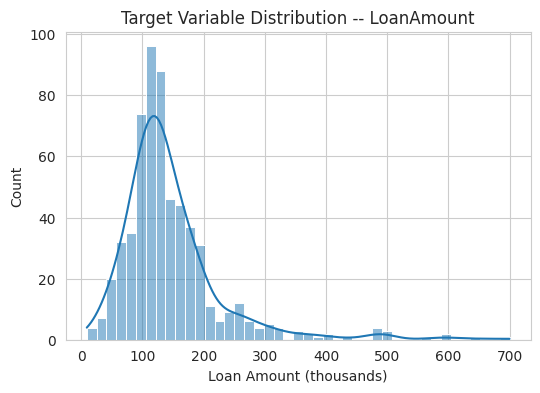

Target skewness: 2.678


In [5]:
plt.figure(figsize=(6,4))
sns.histplot(y, kde=True)
plt.title("Target Variable Distribution -- LoanAmount")
plt.xlabel("Loan Amount (thousands)")
plt.show()
print("Target skewness:", round(y.skew(), 3))

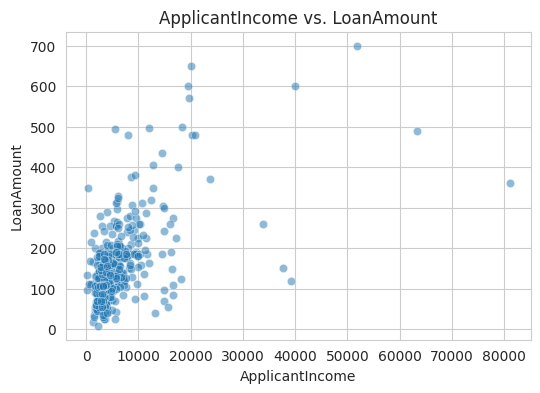

ApplicantIncome correlation with LoanAmount: 0.571


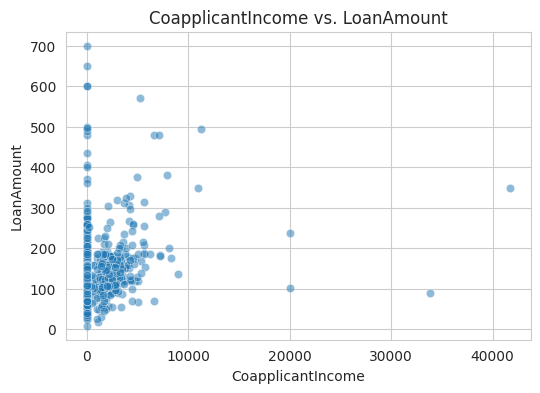

CoapplicantIncome correlation with LoanAmount: 0.189


In [6]:
for feat in ["ApplicantIncome", "CoapplicantIncome"]:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=df[feat], y=y, alpha=0.5)
    plt.title(f"{feat} vs. LoanAmount")
    plt.show()
    print(feat, "correlation with LoanAmount:", round(df[feat].corr(y), 3))

## 4. Train-Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train size:", len(X_train), " Test size:", len(X_test))

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols),
])

Train size: 473  Test size: 119


## 5. Baseline Linear Regression + Cross-Validation / Test Helper Functions

In [8]:
def build_pipe(estimator):
    return Pipeline([("prep", preprocessor), ("model", estimator)])

kf = KFold(n_splits=5, shuffle=True, random_state=42)

def cv_metrics(pipe, X, y):
    maes, mses, rmses, r2s = [], [], [], []
    for tr_idx, val_idx in kf.split(X):
        Xtr, Xval = X.iloc[tr_idx], X.iloc[val_idx]
        ytr, yval = y.iloc[tr_idx], y.iloc[val_idx]
        pipe.fit(Xtr, ytr)
        pred = pipe.predict(Xval)
        maes.append(mean_absolute_error(yval, pred))
        mses.append(mean_squared_error(yval, pred))
        rmses.append(np.sqrt(mean_squared_error(yval, pred)))
        r2s.append(r2_score(yval, pred))
    return dict(MAE=np.mean(maes), MSE=np.mean(mses), RMSE=np.mean(rmses), R2=np.mean(r2s))

def test_metrics(pipe, X_train, y_train, X_test, y_test):
    t0 = time.time()
    pipe.fit(X_train, y_train)
    train_time = time.time() - t0
    pred = pipe.predict(X_test)
    return dict(
        MAE=mean_absolute_error(y_test, pred),
        MSE=mean_squared_error(y_test, pred),
        RMSE=np.sqrt(mean_squared_error(y_test, pred)),
        R2=r2_score(y_test, pred),
        TrainingTime=train_time,
    ), pred

In [9]:
cv_results = {}
test_results = {}
predictions = {}
fitted_pipes = {}

lin_pipe = build_pipe(LinearRegression())
cv_results["Linear Regression"] = cv_metrics(lin_pipe, X_train, y_train)
test_results["Linear Regression"], predictions["Linear Regression"] = test_metrics(lin_pipe, X_train, y_train, X_test, y_test)
fitted_pipes["Linear Regression"] = lin_pipe
cv_results["Linear Regression"], test_results["Linear Regression"]

({'MAE': np.float64(43.464455837104744),
  'MSE': np.float64(5590.813888033079),
  'RMSE': np.float64(74.0143249690556),
  'R2': np.float64(0.3014996623835181)},
 {'MAE': 36.98754483427773,
  'MSE': 3339.9218137764783,
  'RMSE': np.float64(57.79205666678145),
  'R2': 0.09398318319031973,
  'TrainingTime': 0.007099151611328125})

## 6/7. Ridge, Lasso, Elastic Net + GridSearchCV Hyperparameter Tuning

In [10]:
param_grids = {
    "Ridge Regression": (Ridge(random_state=42), {"model__alpha": [0.01, 0.1, 1, 10, 100]}),
    "Lasso Regression": (Lasso(random_state=42, max_iter=10000), {"model__alpha": [0.001, 0.01, 0.1, 1, 10]}),
    "Elastic Net Regression": (ElasticNet(random_state=42, max_iter=10000),
                                {"model__alpha": [0.01, 0.1, 1, 10], "model__l1_ratio": [0.2, 0.5, 0.8]}),
}

tuning_summary = {}

for name, (estimator, grid) in param_grids.items():
    pipe = build_pipe(estimator)
    gs = GridSearchCV(pipe, param_grid=grid, cv=kf, scoring="r2", n_jobs=-1)
    gs.fit(X_train, y_train)
    best_pipe = gs.best_estimator_
    tuning_summary[name] = {"best_params": gs.best_params_, "best_cv_r2": round(gs.best_score_, 4)}
    cv_results[name] = cv_metrics(best_pipe, X_train, y_train)
    test_results[name], predictions[name] = test_metrics(best_pipe, X_train, y_train, X_test, y_test)
    fitted_pipes[name] = best_pipe

tuning_summary

{'Ridge Regression': {'best_params': {'model__alpha': 100},
  'best_cv_r2': np.float64(0.3403)},
 'Lasso Regression': {'best_params': {'model__alpha': 10},
  'best_cv_r2': np.float64(0.3151)},
 'Elastic Net Regression': {'best_params': {'model__alpha': 1,
   'model__l1_ratio': 0.8},
  'best_cv_r2': np.float64(0.3356)}}

## 8. Performance Tables

In [11]:
cv_df = pd.DataFrame(cv_results).T
cv_df

,MAE,MSE,RMSE,R2
Linear Regression,43.464456,5590.813888,74.014325,0.301500
Ridge Regression,44.495524,5199.021922,71.797816,0.340343
Lasso Regression,46.447922,5435.539932,73.311878,0.315095
Elastic Net Regression,44.445533,5244.726827,72.098826,0.335566


In [12]:
test_df = pd.DataFrame(test_results).T
test_df

,MAE,MSE,RMSE,R2,TrainingTime
Linear Regression,36.987545,3339.921814,57.792057,0.093983,0.007099
Ridge Regression,36.840536,3079.738067,55.495388,0.164563,0.007655
Lasso Regression,37.797084,3181.254854,56.402614,0.137025,0.007177
Elastic Net Regression,36.810933,3087.844347,55.568375,0.162364,0.009541


## 9. Predicted vs. Actual and Residual Plots (Best Model)

In [13]:
best_model_name = min(test_results, key=lambda k: test_results[k]["RMSE"])
print("Best model by test RMSE:", best_model_name)
best_pred = predictions[best_model_name]

Best model by test RMSE: Ridge Regression


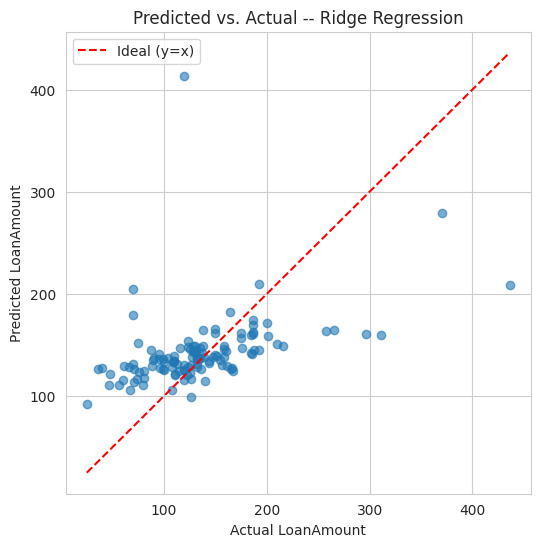

In [14]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, best_pred, alpha=0.6)
lims = [min(y_test.min(), best_pred.min()), max(y_test.max(), best_pred.max())]
plt.plot(lims, lims, "r--", label="Ideal (y=x)")
plt.xlabel("Actual LoanAmount")
plt.ylabel("Predicted LoanAmount")
plt.title(f"Predicted vs. Actual -- {best_model_name}")
plt.legend()
plt.show()

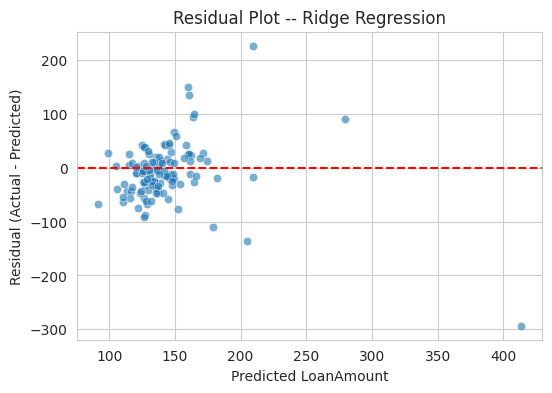

Residual mean: -7.765  std: 54.949


In [15]:
residuals = y_test.values - best_pred
plt.figure(figsize=(6,4))
sns.scatterplot(x=best_pred, y=residuals, alpha=0.6)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted LoanAmount")
plt.ylabel("Residual (Actual - Predicted)")
plt.title(f"Residual Plot -- {best_model_name}")
plt.show()
print("Residual mean:", round(residuals.mean(), 3), " std:", round(residuals.std(), 3))

## 10. Training Error vs. Validation Error (Learning Curve)

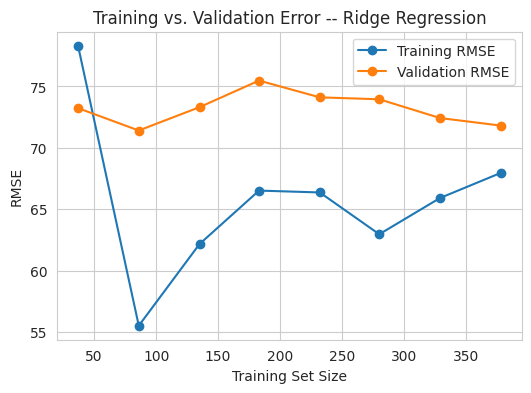

In [16]:
train_sizes, train_scores, val_scores = learning_curve(
    fitted_pipes[best_model_name], X_train, y_train, cv=kf,
    scoring="neg_root_mean_squared_error",
    train_sizes=np.linspace(0.1, 1.0, 8), random_state=42
)
train_rmse = -train_scores.mean(axis=1)
val_rmse = -val_scores.mean(axis=1)

plt.figure(figsize=(6,4))
plt.plot(train_sizes, train_rmse, "o-", label="Training RMSE")
plt.plot(train_sizes, val_rmse, "o-", label="Validation RMSE")
plt.xlabel("Training Set Size")
plt.ylabel("RMSE")
plt.title(f"Training vs. Validation Error -- {best_model_name}")
plt.legend()
plt.show()

## 11. Coefficient Comparison Across Models

In [17]:
feature_names = fitted_pipes["Linear Regression"].named_steps["prep"].get_feature_names_out()
coef_table = pd.DataFrame({"Feature": feature_names})
for name in ["Linear Regression", "Ridge Regression", "Lasso Regression", "Elastic Net Regression"]:
    coef_table[name] = fitted_pipes[name].named_steps["model"].coef_

coef_table_sorted = coef_table.reindex(coef_table["Linear Regression"].abs().sort_values(ascending=False).index)
top_feats = coef_table_sorted.head(8)
top_feats

,Feature,Linear Regression,Ridge Regression,Lasso Regression,Elastic Net Regression
0,num__ApplicantIncome,53.683425,45.115476,45.096484,45.141385
1,num__CoapplicantIncome,22.064400,17.762016,11.914155,17.429032
5,cat__Married_Yes,20.098849,11.683104,0.000000,10.709631
10,cat__Self_Employed_Yes,18.507513,8.028961,0.000000,5.974622
8,cat__Dependents_3+,17.640978,6.199097,0.000000,3.425831
9,cat__Education_Not Graduate,-15.910552,-8.464711,-0.000000,-6.523966
6,cat__Dependents_1,12.836219,4.882928,0.000000,2.406359
12,cat__Property_Area_Urban,-12.339803,-4.982399,-0.000000,-3.042154


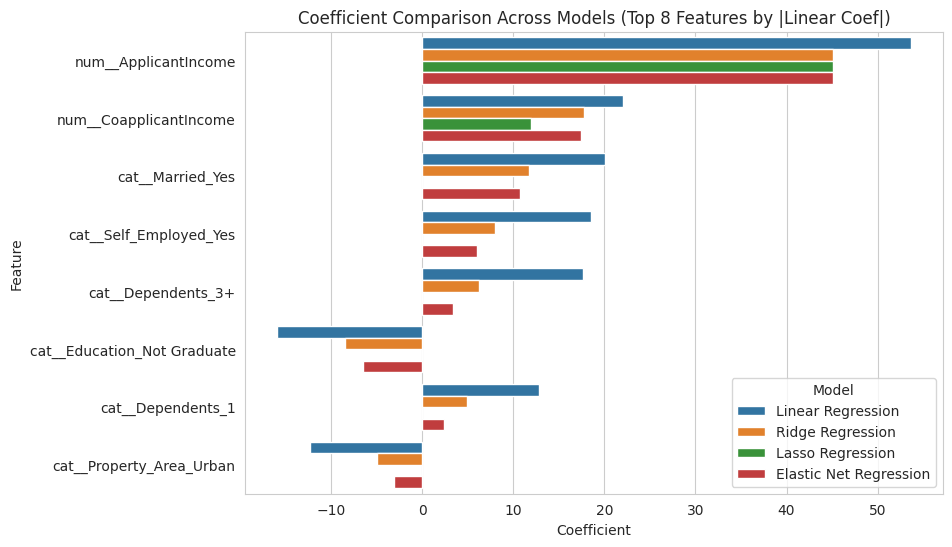

In [18]:
melted = top_feats.melt(id_vars="Feature", var_name="Model", value_name="Coefficient")
plt.figure(figsize=(9,6))
sns.barplot(data=melted, x="Coefficient", y="Feature", hue="Model")
plt.title("Coefficient Comparison Across Models (Top 8 Features by |Linear Coef|)")
plt.show()

## 12. Summary

See the accompanying report (`Experiment3.pdf`) for the full discussion of overfitting/underfitting and bias-variance analysis grounded in these results.